In [1]:
from src.dataset import ThingsEEGDataset
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Get train dataset, all subjects
train_data = ThingsEEGDataset(data_type="train")

2026-05-08 21:31:25.632 | INFO     | src.dataset:__init__:268 - dataset_dir=./data/things_eeg device=cpu found_subjects=10
2026-05-08 21:31:25.632 | INFO     | src.dataset:__init__:269 - Loadding EEG data from each subject...
2026-05-08 21:31:35.007 | INFO     | src.dataset:__init__:274 - Loading image metadata...
2026-05-08 21:31:35.021 | INFO     | src.dataset:__init__:279 - Loading image data...
2026-05-08 21:32:09.897 | INFO     | src.dataset:__init__:284 - ThingsEEGDataset
Number of subjects loaded : 10
Total samples : 661600
Samples per subject without repetition : 16540
Number of repetitions : 4
Number of images : 1654
Number of samples per image : 10
2026-05-08 21:32:09.899 | INFO     | src.dataset:__init__:300 - EEG data loaded successfully.


# Example usage

In [3]:
# get the first sample
eeg_sample, image_sample, subject_index, repetition_index, data_index, image_concept, image_file = train_data[0]
print(f"EEG sample shape: {eeg_sample.shape}")
print(f"Image sample shape: {image_sample.shape}")
print(f"Subject index: {subject_index}")
print(f"Repetition index: {repetition_index}")
print(f"Data index: {data_index}")
print(f"Image concept: {image_concept}")
print(f"Image file: {image_file}")

EEG sample shape: torch.Size([17, 100])
Image sample shape: torch.Size([3, 500, 500])
Subject index: 0
Repetition index: 0
Data index: 0
Image concept: 00001_aardvark
Image file: aardvark_01b.jpg


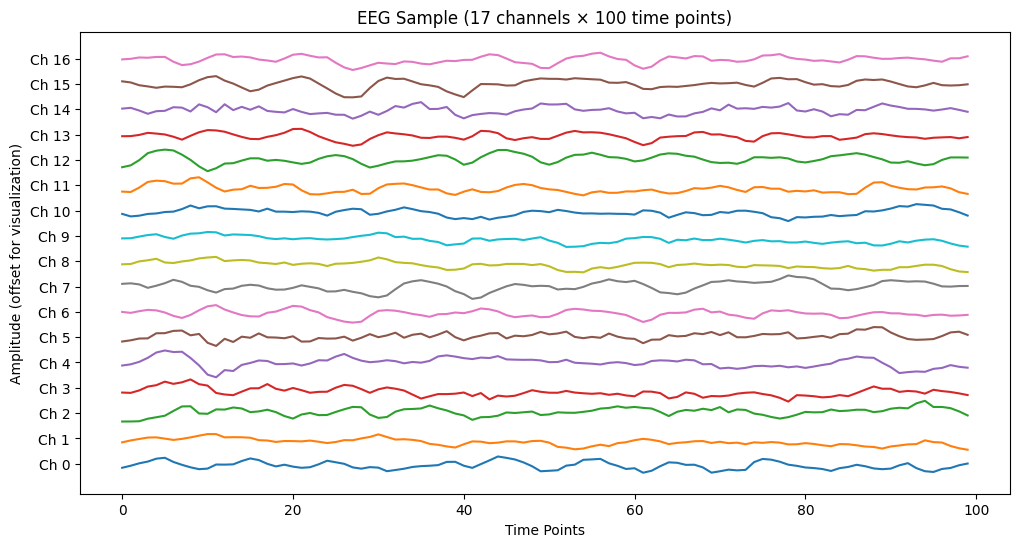

In [4]:
# Visualize the EEG sample (17 channels × 100 time points)
plt.figure(figsize=(12, 6))
for channel in range(eeg_sample.shape[0]):
    plt.plot(eeg_sample[channel].cpu().numpy() + channel * 5)  # Offset each channel for better visualization
plt.title("EEG Sample (17 channels × 100 time points)")
plt.xlabel("Time Points")
plt.ylabel("Amplitude (offset for visualization)")
plt.yticks(np.arange(0, eeg_sample.shape[0] * 5, 5), [f"Ch {i}" for i in range(eeg_sample.shape[0])])
plt.show()

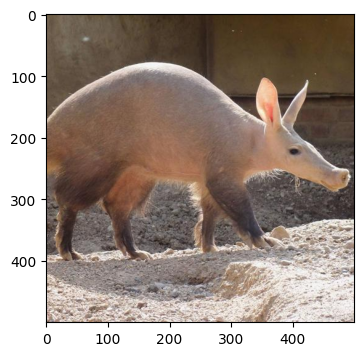

In [5]:
# Viz the image sample
plt.figure(figsize=(4, 4))
plt.imshow(image_sample.cpu().permute(1, 2, 0))  # Convert from (C, H, W) to (H, W, C) for visualization

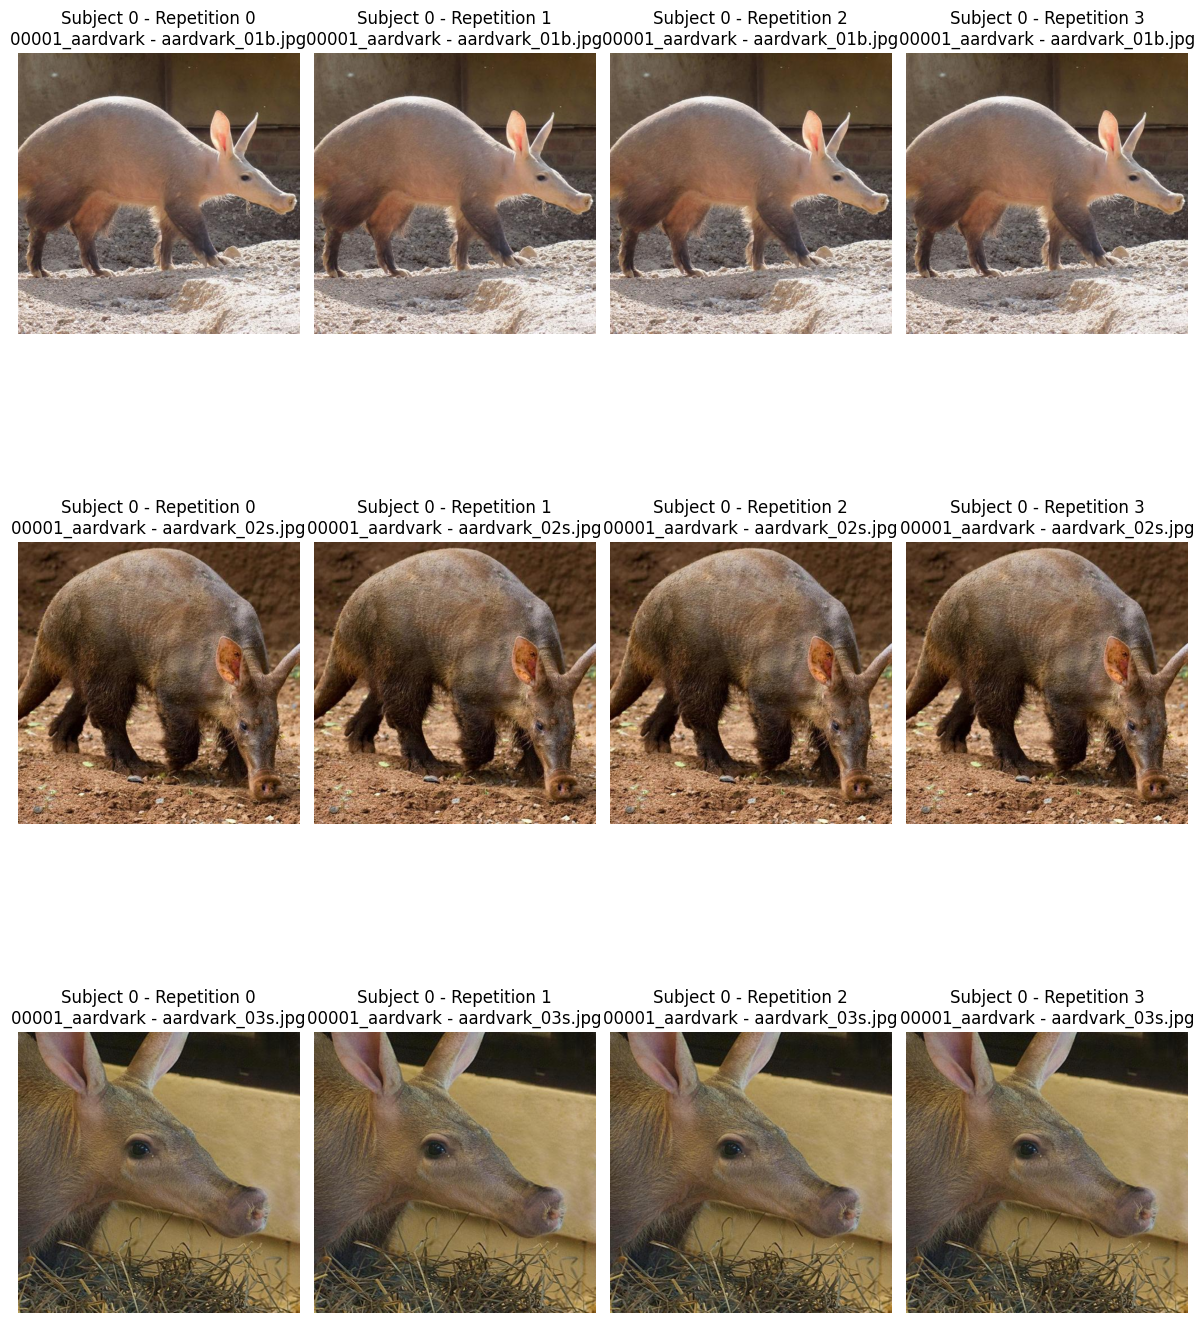

In [6]:
# viz first 12 samepl of the same subject using 3x4 subplots

fig, axes = plt.subplots(3, 4, figsize=(12, 16))
for i in range(12):
    eeg_sample, image_sample, subject_index, repetition_index, data_index, image_concept, image_file = train_data[i]
    ax = axes[i // 4, i % 4]
    ax.imshow(image_sample.cpu().permute(1, 2, 0))
    ax.set_title(f"Subject {subject_index} - Repetition {repetition_index}\n{image_concept} - {image_file}")
    ax.axis('off')
plt.tight_layout()
plt.show()

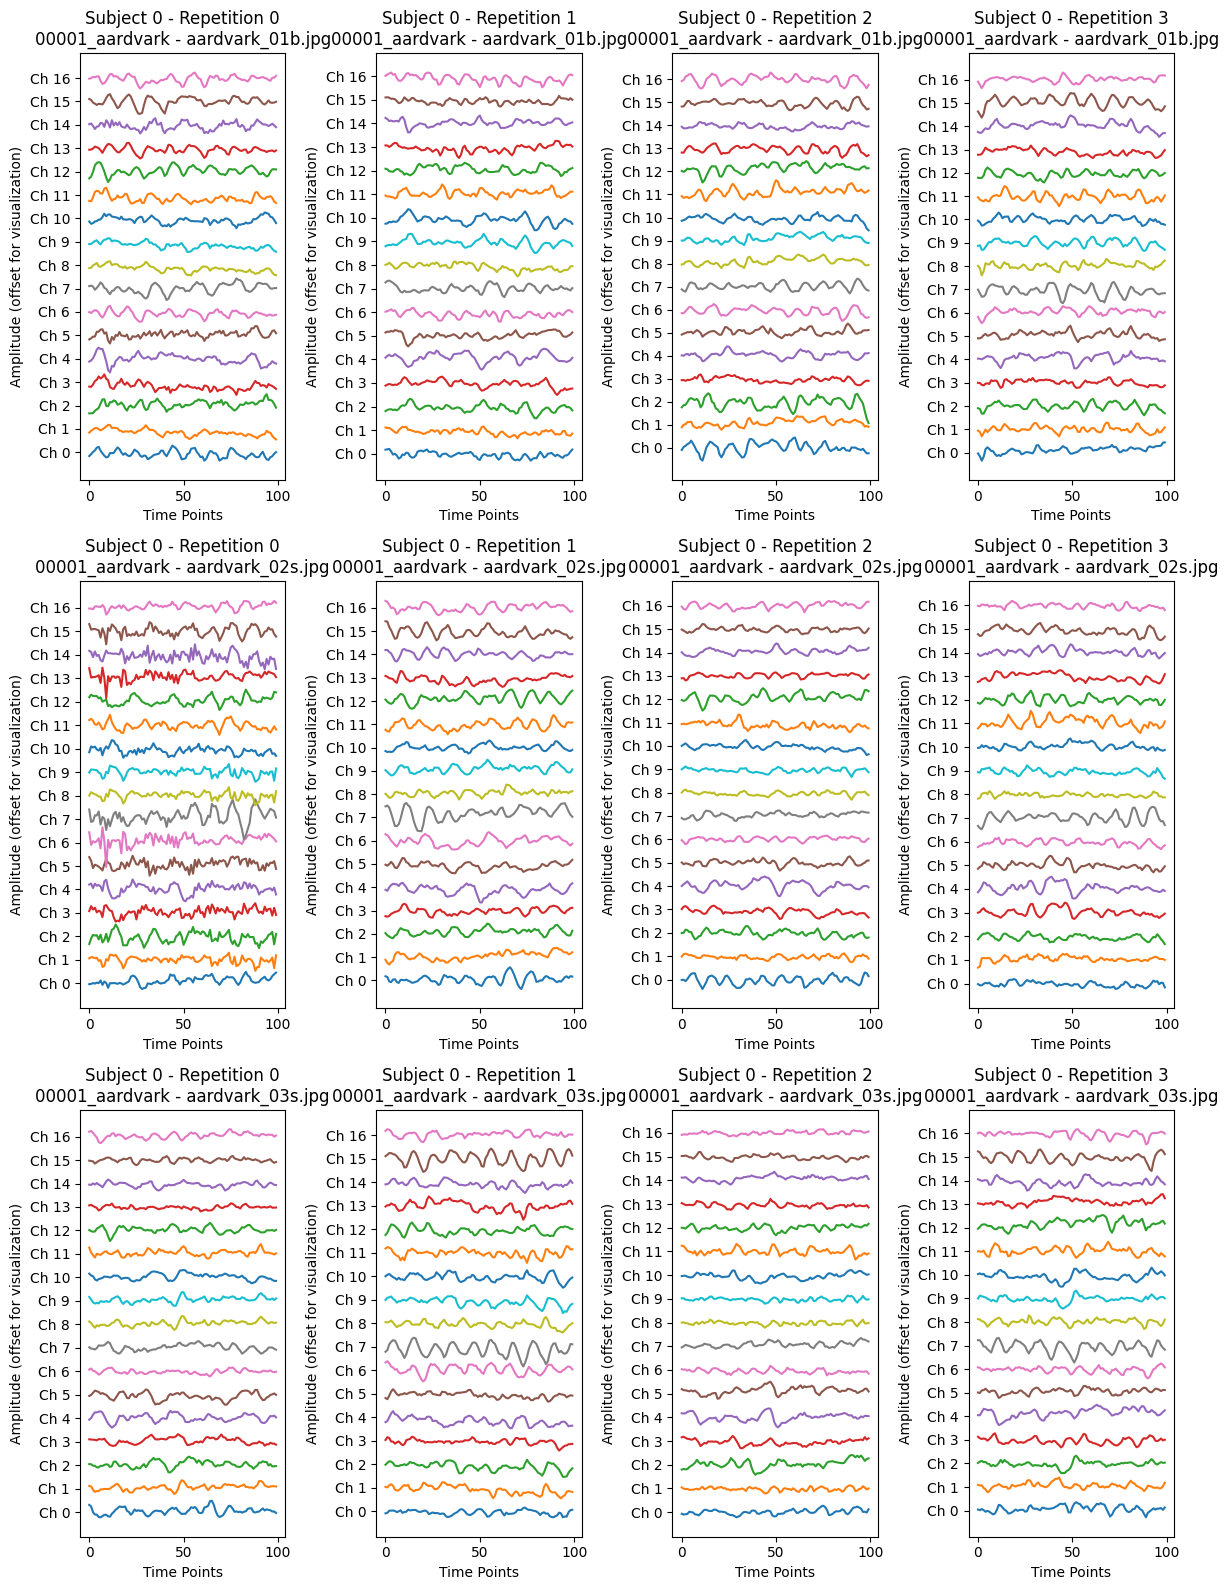

In [7]:
# viz first 12 sample of the same subject using 3x4 subplots with eeg

fig, axes = plt.subplots(3, 4, figsize=(12, 16))
for i in range(12):
    eeg_sample, image_sample, subject_index, repetition_index, data_index, image_concept, image_file = train_data[i]
    ax = axes[i // 4, i % 4]
    for channel in range(eeg_sample.shape[0]):
        ax.plot(eeg_sample[channel].cpu().numpy() + channel * 5)  # Offset each channel for better visualization
    ax.set_title(f"Subject {subject_index} - Repetition {repetition_index}\n{image_concept} - {image_file}")
    ax.set_xlabel("Time Points")
    ax.set_ylabel("Amplitude (offset for visualization)")
    ax.set_yticks(np.arange(0, eeg_sample.shape[0] * 5, 5))
    ax.set_yticklabels([f"Ch {i}" for i in range(eeg_sample.shape[0])])
plt.tight_layout()
plt.show()

# Example load train and test

In [8]:
# Get only one subject's data
train_data = ThingsEEGDataset(data_type="train", subject=1)
test_data = ThingsEEGDataset(data_type="test", subject=1)

2026-05-08 21:32:28.601 | INFO     | src.dataset:__init__:268 - dataset_dir=./data/things_eeg device=cpu found_subjects=10
2026-05-08 21:32:28.601 | INFO     | src.dataset:__init__:269 - Loadding EEG data from each subject...
2026-05-08 21:32:29.448 | INFO     | src.dataset:__init__:274 - Loading image metadata...
2026-05-08 21:32:29.468 | INFO     | src.dataset:__init__:279 - Loading image data...
2026-05-08 21:33:11.231 | INFO     | src.dataset:__init__:284 - ThingsEEGDataset
Number of subjects loaded : 1
Total samples : 66160
Samples per subject without repetition : 16540
Number of repetitions : 4
Number of images : 1654
Number of samples per image : 10
2026-05-08 21:33:11.232 | INFO     | src.dataset:__init__:300 - EEG data loaded successfully.
2026-05-08 21:33:12.454 | INFO     | src.dataset:__init__:268 - dataset_dir=./data/things_eeg device=cpu found_subjects=10
2026-05-08 21:33:12.454 | INFO     | src.dataset:__init__:269 - Loadding EEG data from each subject...
2026-05-08 21:3